In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from typing import Union, Dict
import joblib


In [18]:

PLOT_COLORS = {
    'primary': '#2a78d6',
    'secondary': '#eb6834',
    'tertiary': '#1baf7a',
    'error': '#e34948',
    'zero_line': 'red'
}


In [19]:
# Load lại model
best_casual = joblib.load("models/best_casual_rf.joblib")
# Load lại model
best_registered = joblib.load("models/best_registered_rf.joblib")

In [20]:
X_test_casual = pd.read_csv("../datas/X_test_casual.csv")
X_test_registered = pd.read_csv("../datas/X_test_registered.csv")

In [21]:
X_test_casual.info()

<class 'pandas.DataFrame'>
RangeIndex: 3476 entries, 0 to 3475
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   yr                  3476 non-null   int64  
 1   mnth                3476 non-null   int64  
 2   hr                  3476 non-null   int64  
 3   weekday             3476 non-null   int64  
 4   workingday          3476 non-null   int64  
 5   weathersit          3476 non-null   int64  
 6   atemp               3476 non-null   float64
 7   hum                 3476 non-null   float64
 8   is_weekend_leisure  3476 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 244.5 KB


In [22]:
cat_cols = ["mnth","hr","yr","weekday","workingday","is_weekend_leisure"]
X_test_casual[cat_cols] = X_test_casual[cat_cols].astype("category")
cat_cols = ["mnth","hr","yr","weekday","workingday","is_weekend_leisure","is_rush_hour"]
X_test_registered[cat_cols] = X_test_registered[cat_cols].astype("category")

In [23]:
y_test_casual = pd.read_csv("../datas/y_test_casual.csv")
y_test_registered = pd.read_csv("../datas/y_test_registered.csv")

In [24]:
def calculate_metrics(y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]) -> Dict[str, float]:
    """Calculates core evaluation metrics strictly without formatting."""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # Avoid div-by-zero for MAPE
    mask = y_true != 0

    mse = mean_squared_error(y_true, y_pred)

    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mse),
        'RMSLE': np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred, 0, None)))),
        'MAPE': mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    }


In [25]:

def generate_evaluation_report(metrics: Dict[str, float]) -> pd.DataFrame:
    """Formats raw metrics into a presentation-ready DataFrame."""
    return pd.DataFrame({
        'Metric': ['R²', 'RMSE', 'RMSLE', 'MAPE (%)'],
        'Score': [
            round(metrics['R2'], 4),
            round(metrics['RMSE'], 2),
            round(metrics['RMSLE'], 4),
            round(metrics['MAPE'], 2)
        ],
        'Diễn giải': [
            'Tỷ lệ phương sai giải thích được (càng gần 1 càng tốt)',
            'Căn bậc hai của sai số bình phương trung bình (cùng đơn vị target)',
            'RMSE trên log-scale, ít nhạy cảm với outlier',
            'Sai số phần trăm tuyệt đối trung bình (dễ hiểu)',
        ]
    })


In [26]:

# --- Plotting Functions ---
def plot_evaluate_sorted(y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series]) -> None:
    """Plots actuals vs predicted values sorted by actuals."""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    idx = np.argsort(y_true)
    y_true_s, y_pred_s = y_true[idx], y_pred[idx]
    x = np.arange(len(y_true_s))
    residuals = y_true_s - y_pred_s

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Plot 1: Actual vs Predicted
    axes[0].scatter(x, y_pred_s, color=PLOT_COLORS['primary'], s=10, alpha=0.5, label='Predicted', zorder=2)
    axes[0].plot(x, y_true_s, color=PLOT_COLORS['secondary'], linewidth=2, label='Actual', zorder=3)
    axes[0].set_title('Actual vs Predicted (sorted by actual)', fontsize=13)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Residuals
    axes[1].scatter(x, residuals, color=PLOT_COLORS['primary'], s=10, alpha=0.4, zorder=2)
    axes[1].axhline(0, color=PLOT_COLORS['error'], linewidth=2, linestyle='--', label='Zero error')
    axes[1].fill_between(x, residuals, 0, where=(residuals > 0), alpha=0.1, color=PLOT_COLORS['secondary'], label='Under-predict')
    axes[1].fill_between(x, residuals, 0, where=(residuals < 0), alpha=0.1, color=PLOT_COLORS['primary'], label='Over-predict')
    axes[1].set_title('Residuals (Actual - Predicted)', fontsize=13)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot 3: Residual Distribution
    sns.histplot(residuals, kde=True, ax=axes[2], color="#ff7f0e", bins=20, stat="density")
    axes[2].axvline(x=0, color=PLOT_COLORS['zero_line'], linestyle="--", lw=2, label="Zero Error Line")
    axes[2].set_title("Residual Distribution")
    axes[2].set(xlabel="Residual Value", ylabel="Density")
    axes[2].legend()
    axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout() # FIX: Removed the duplicate call
    plt.show()



In [27]:
def plot_residual_diagnostics(y_true: Union[np.ndarray, pd.Series], y_pred: Union[np.ndarray, pd.Series], model_name: str = "Model") -> None:
    """Plots residual diagnostics for model evaluation."""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Residual Diagnostics — {model_name}', fontsize=14, fontweight='bold')

    # Residual vs Predicted
    axes[0,0].scatter(y_pred, residuals, alpha=0.3, s=10, color=PLOT_COLORS['primary'])
    axes[0,0].axhline(0, color=PLOT_COLORS['zero_line'], linewidth=1.5, linestyle='--')
    axes[0,0].set_title('Residual vs Predicted', fontsize=11)

    # Q-Q Plot
    stats.probplot(residuals, dist='norm', plot=axes[0,1])
    axes[0,1].set_title('Q-Q Plot', fontsize=11)

    # Residual Distribution
    sns.histplot(residuals, kde=True, ax=axes[1,0], color=PLOT_COLORS['secondary'], bins=40, stat='density')
    axes[1,0].axvline(0, color=PLOT_COLORS['zero_line'], linestyle='--')
    axes[1,0].set_title('Phân phối Residual', fontsize=11)

    # Scale-Location
    axes[1,1].scatter(y_pred, np.sqrt(np.abs(residuals)), alpha=0.3, s=10, color=PLOT_COLORS['tertiary'])
    axes[1,1].set_title('Scale-Location', fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f'\n── Thống kê mô tả residual ({model_name}) ──')
    print(f'Mean residual : {residuals.mean():.4f}')
    print(f'Std residual  : {residuals.std():.4f}')


In [28]:
y_pred_cas = best_casual.predict(X_test_casual)
y_pred_reg = best_registered.predict(X_test_registered)


Casual Evaluation:


,Metric,Score,Diễn giải
0,R²,0.8748,Tỷ lệ phương sai giải thích được (càng gần 1 c...
1,RMSE,19.8100,Căn bậc hai của sai số bình phương trung bình ...
2,RMSLE,0.5563,"RMSE trên log-scale, ít nhạy cảm với outlier"
3,MAPE (%),52.9500,Sai số phần trăm tuyệt đối trung bình (dễ hiểu)


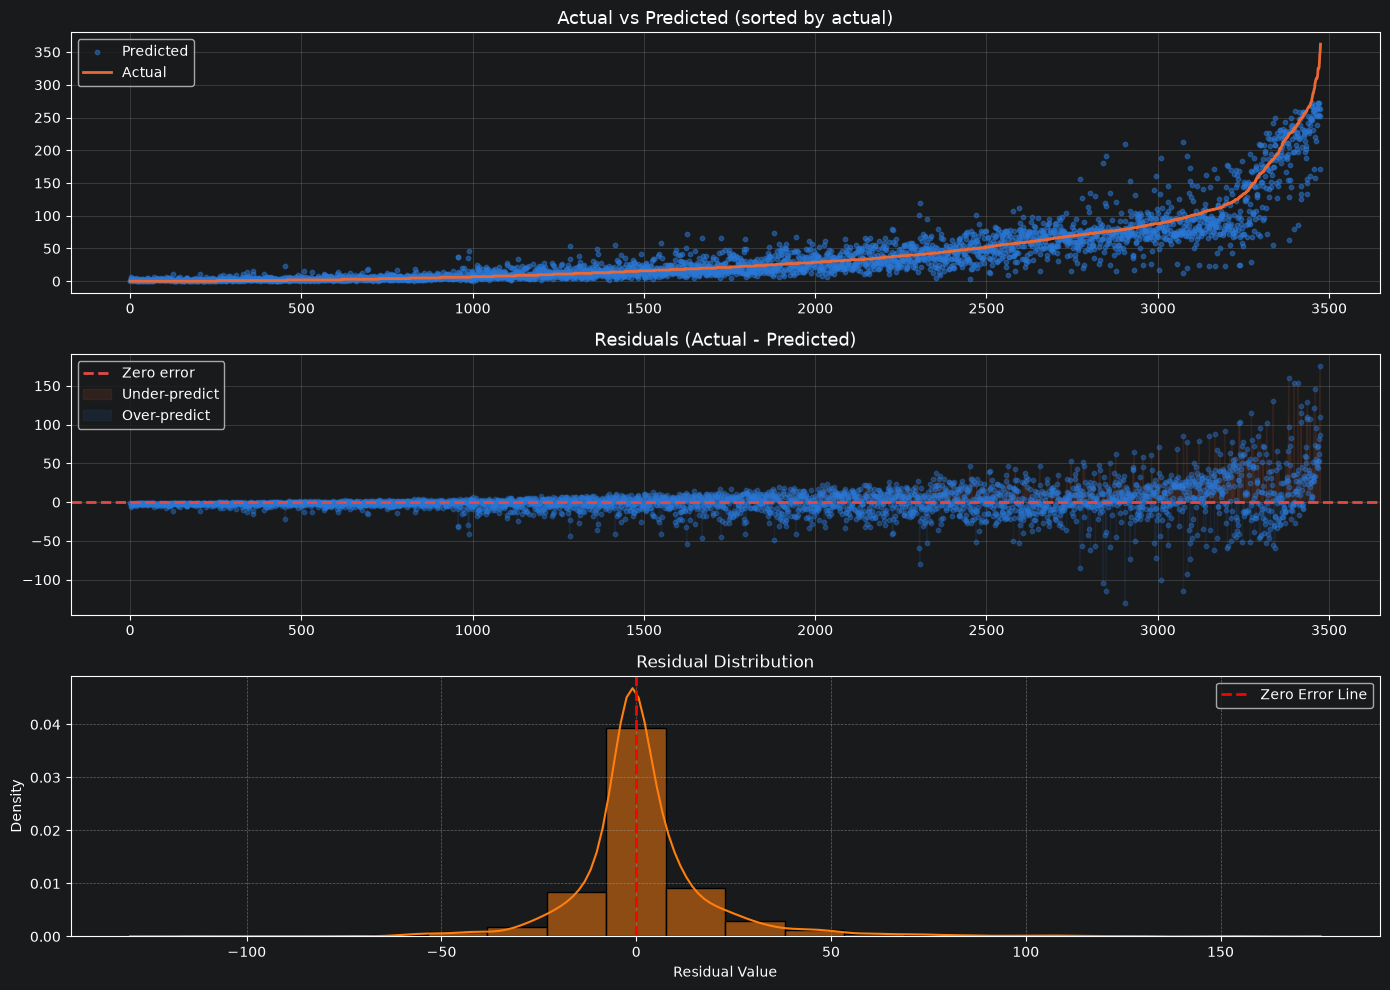

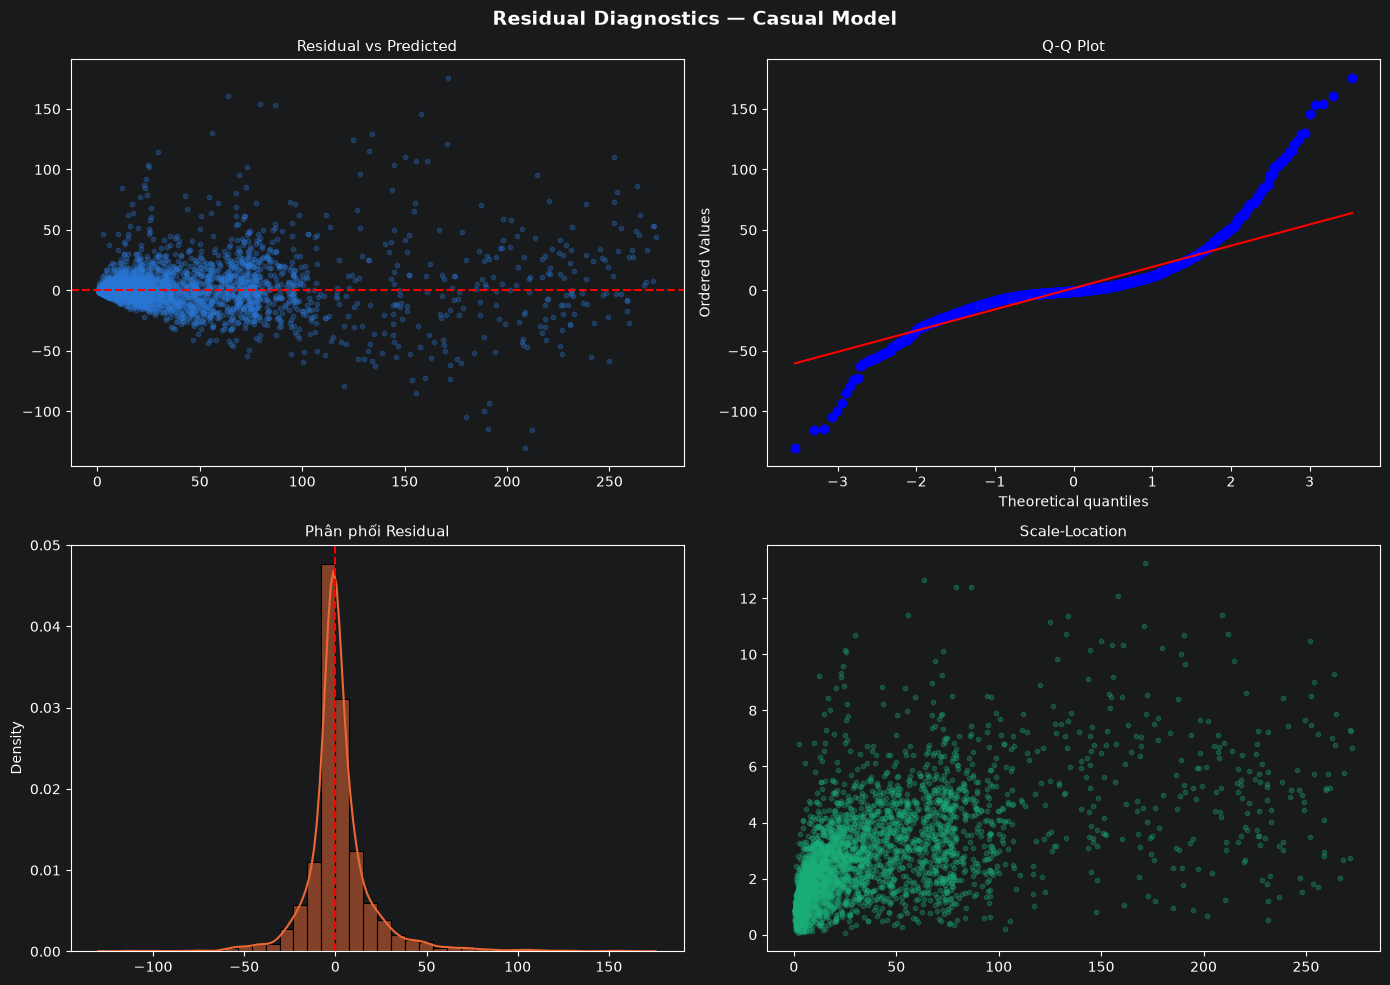


── Thống kê mô tả residual (Casual Model) ──
Mean residual : 1.8801
Std residual  : 19.7238


In [29]:
print("Casual Evaluation:")
cas_metrics = calculate_metrics(y_test_casual, y_pred_cas)
display(generate_evaluation_report(cas_metrics))
plot_evaluate_sorted(y_test_casual, y_pred_cas)
plot_residual_diagnostics(y_test_casual, y_pred_cas, "Casual Model")



Registered Evaluation:


,Metric,Score,Diễn giải
0,R²,0.8957,Tỷ lệ phương sai giải thích được (càng gần 1 c...
1,RMSE,60.7900,Căn bậc hai của sai số bình phương trung bình ...
2,RMSLE,0.4055,"RMSE trên log-scale, ít nhạy cảm với outlier"
3,MAPE (%),37.4600,Sai số phần trăm tuyệt đối trung bình (dễ hiểu)


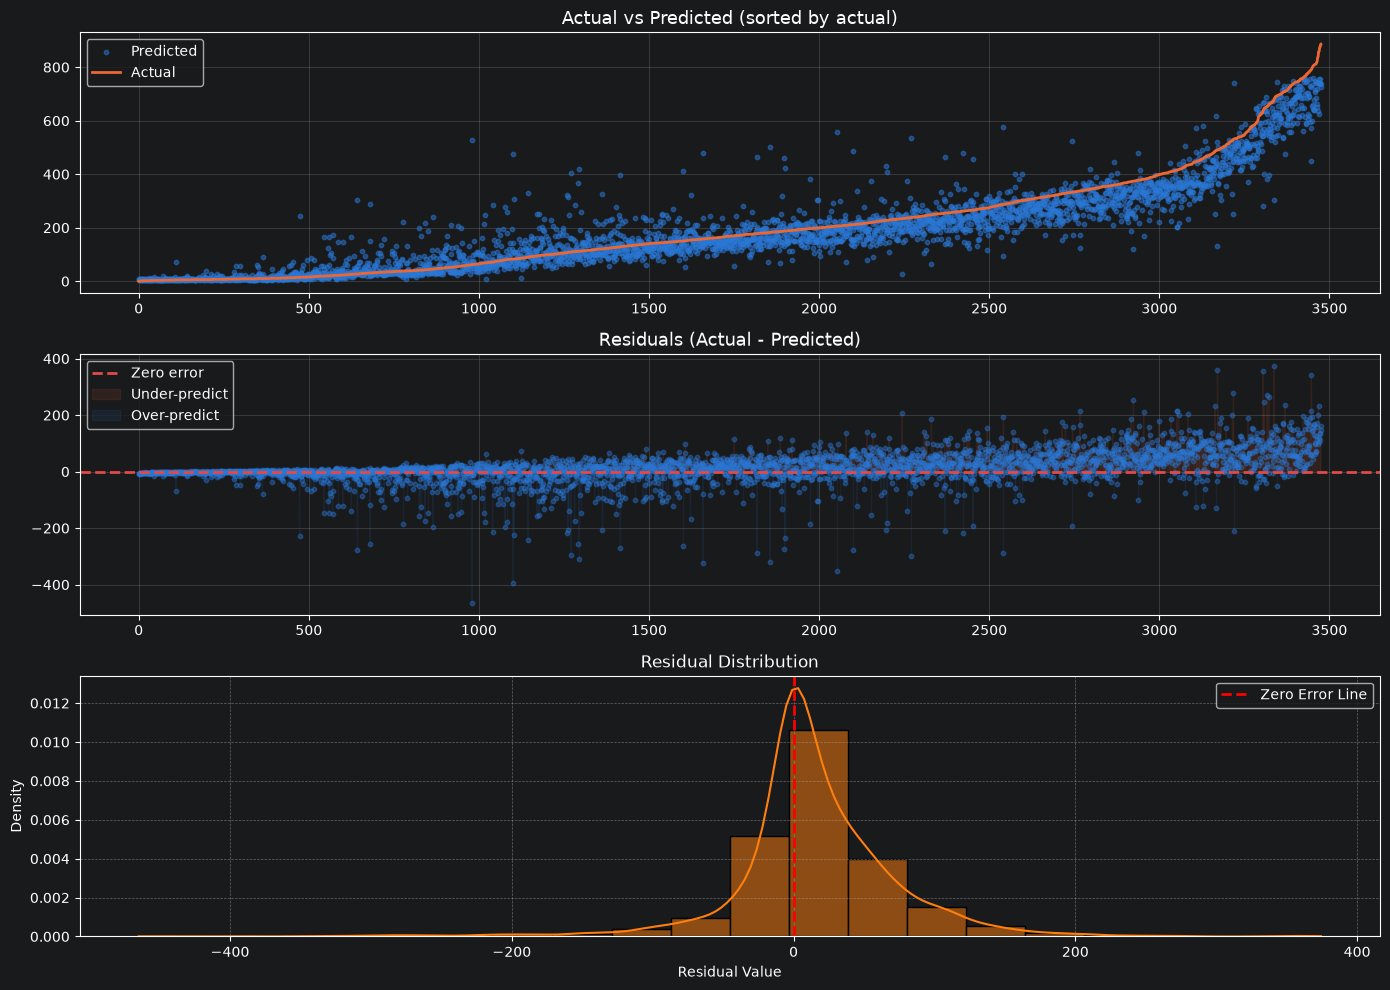

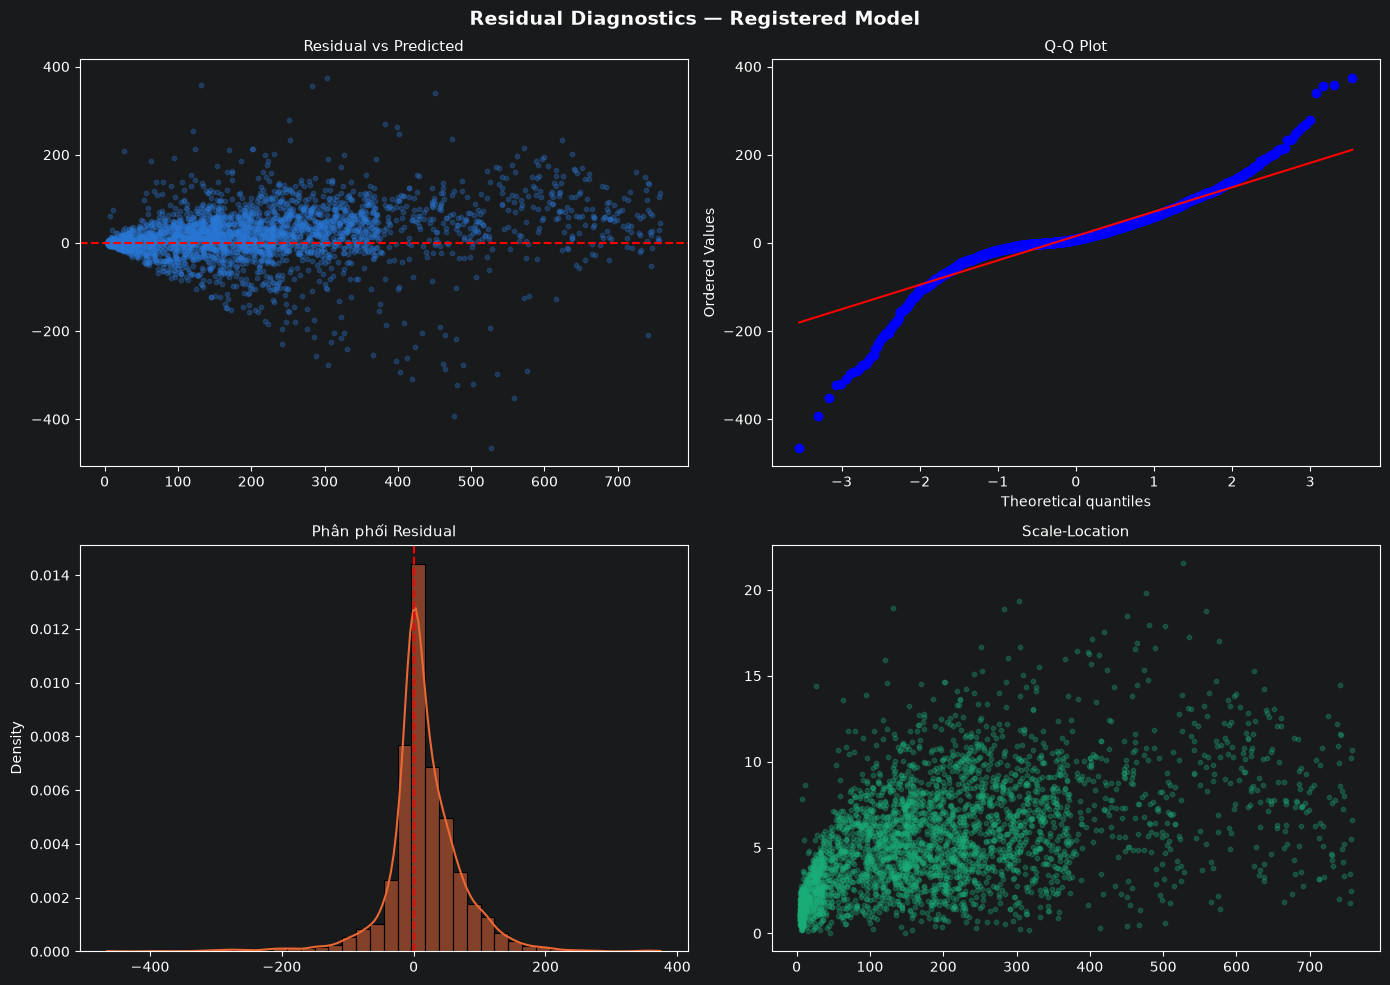


── Thống kê mô tả residual (Registered Model) ──
Mean residual : 15.3069
Std residual  : 58.8326


In [30]:
print("\nRegistered Evaluation:")
reg_metrics = calculate_metrics(y_test_registered, y_pred_reg)
display(generate_evaluation_report(reg_metrics))
plot_evaluate_sorted(y_test_registered, y_pred_reg)
plot_residual_diagnostics(y_test_registered, y_pred_reg, "Registered Model")


In [31]:
print("\nTotal (Casual + Registered) Evaluation:")
y_pred_total = y_pred_cas + y_pred_reg
y_test_total = y_test_registered.iloc[:, 0] + y_test_casual.iloc[:, 0]



Total (Casual + Registered) Evaluation:


,Metric,Score,Diễn giải
0,R²,0.9023,Tỷ lệ phương sai giải thích được (càng gần 1 c...
1,RMSE,68.9100,Căn bậc hai của sai số bình phương trung bình ...
2,RMSLE,0.3973,"RMSE trên log-scale, ít nhạy cảm với outlier"
3,MAPE (%),36.4600,Sai số phần trăm tuyệt đối trung bình (dễ hiểu)


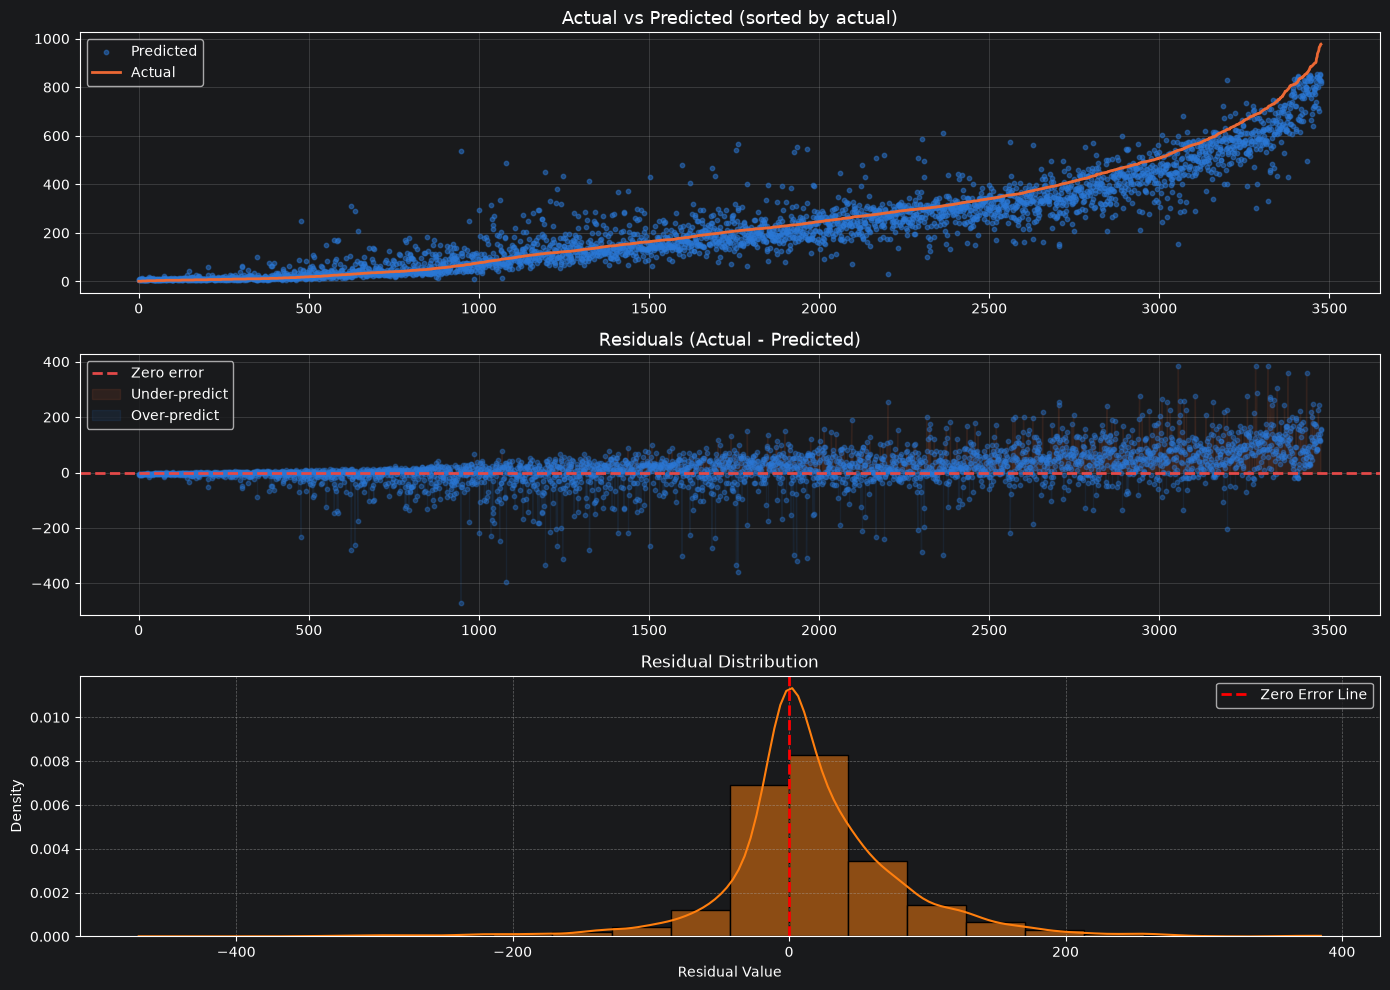

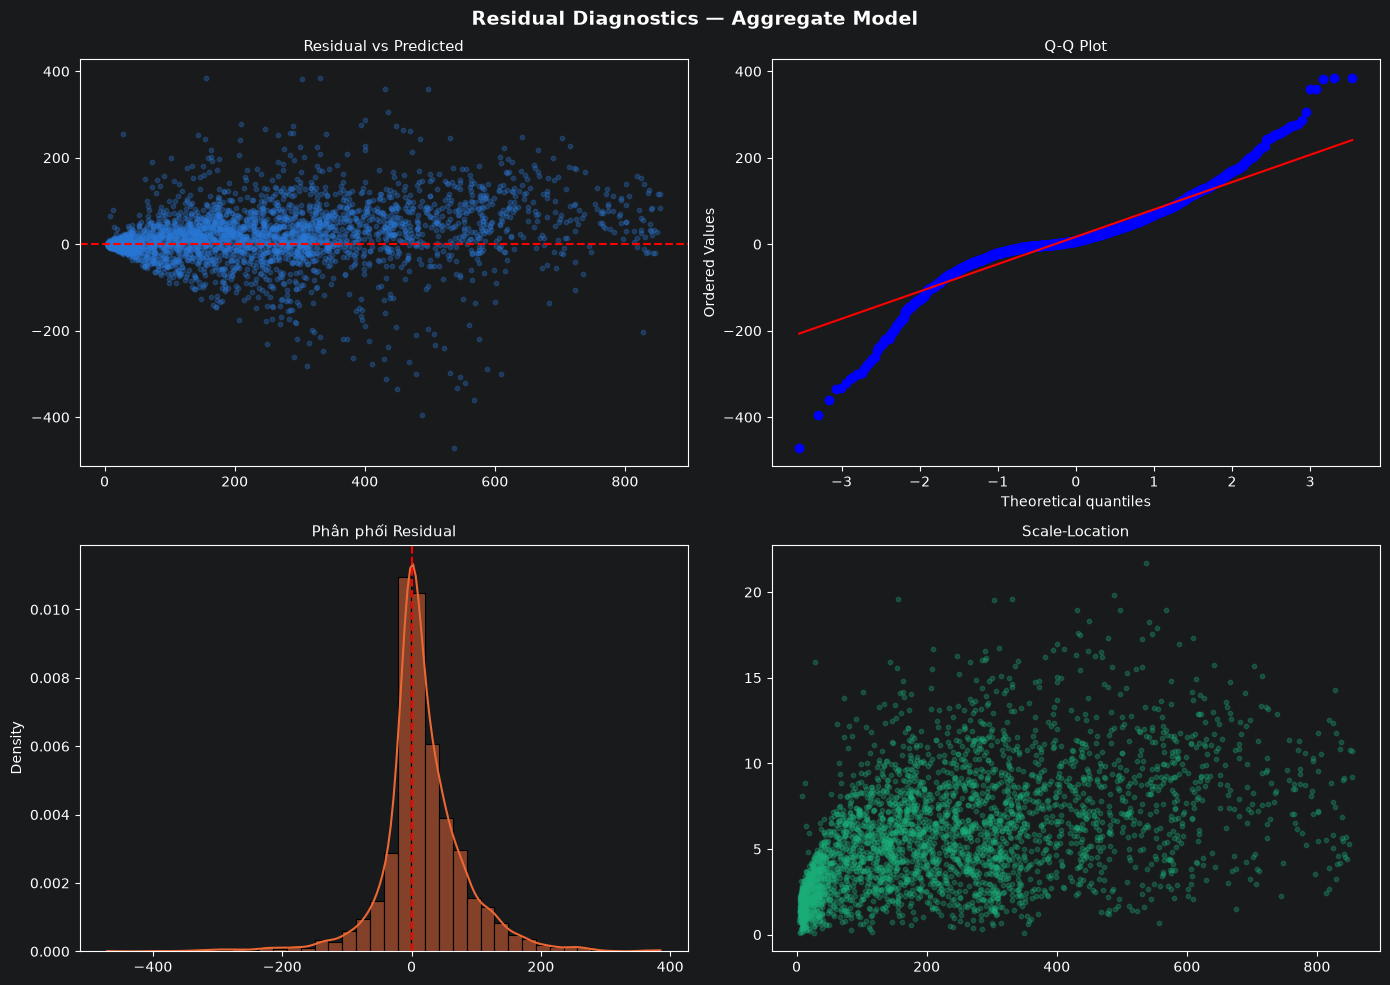


── Thống kê mô tả residual (Aggregate Model) ──
Mean residual : 17.1869
Std residual  : 66.7330


In [32]:
total_metrics = calculate_metrics(y_test_total, y_pred_total)
display(generate_evaluation_report(total_metrics))
plot_evaluate_sorted(y_test_total, y_pred_total)
plot_residual_diagnostics(y_test_total, y_pred_total, "Aggregate Model")